# Single-Cell/Nuclear RNA-Seq Analysis analysis to explore opioid use disorder

## Introduction

The incidence rate of opioid use disorder (OUD) has massively increased, particularly in the United States. In order to understand the molecular changes associated with OUD, single-nuclear RNA data was taken from 12 individuals, six of which have OUD with the other six being normal - each of these subsamples have an equal number of females and males. The samples were taken from the dorsal striatum, a region in the deep brain associated with learnt behaviour and skill acquisition. The annotated data was taken from GEO from the SuperSeries accession number GSE233279, the data is also available in .h5ad file format in a web portal (https://cellxgene.cziscience.com/collections/cec4ef8e-1e70-49a2-ae43-1e6bf1fd5978). For the purposes of this analysis, only the data from human dorsal striatum was used.

The aim of this single-cell/nuclear RNA-seq analysis is as follows:

* Investigate if marker-genes clusters corresponds to known cell types

* Investigate differential gene expression between OUD and normal individuals

* Investigate potential signalling pathways associated with genes implicated in OUD

In [1]:
!pip install -q scanpy
!pip install -q pydeseq2
!pip install -q sc-toolbox
!pip install -q decoupler
!pip install -q scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 4.5 MB/s eta 0:00:00


In [2]:
# load relevant libraries
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import seaborn.objects as so
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import pydeseq2
import sc_toolbox
import decoupler

##Load in snRNA-Seq data from google drive

In [3]:
# Mount drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# load data
adata = sc.read_h5ad(
    "/content/drive/MyDrive/BRN/4125467a-9cf8-4680-a8fa-56203763a89b.h5ad"
)

## Preprocessing and Quality Control

Cells with fewer than 200 genes and genes that are found in fewer than 3 cells, were removed from the adata object. This is done to exclude barcodes containing doublets, dying cells or ambient RNA

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

Mitochondrial genes are annotated within the andata object and quality controls metrics were calculated

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

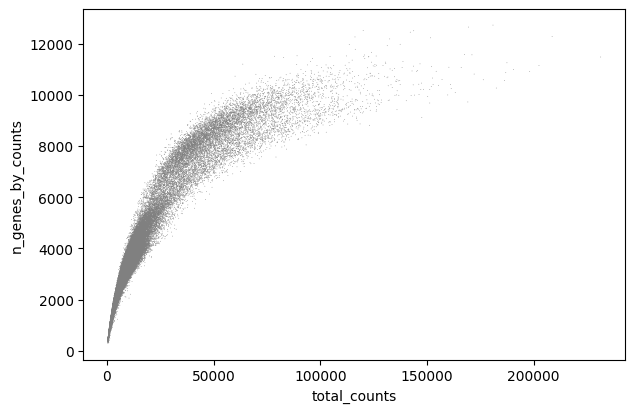

In [7]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

As the dataset is specifically generated from single-nuclei RNA-seq, there were no mitochondrial genes.

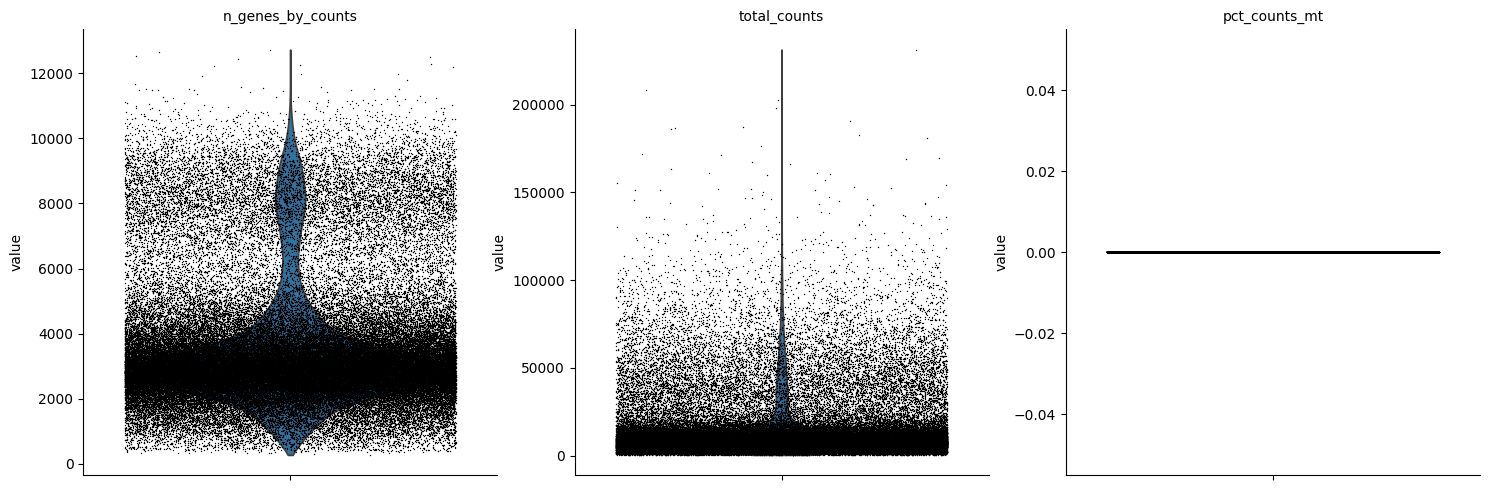

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [9]:
# filter outlier counts based on quartiles
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, 0.98)
lower_lim = np.quantile(adata.obs.n_genes_by_counts.values, 0.02)
print(f"{lower_lim} to {upper_lim}")

999.0 to 9240.0


In [10]:
# filter
adata = adata[
    (adata.obs.n_genes_by_counts < upper_lim)
    & (adata.obs.n_genes_by_counts > lower_lim)
]

Before normalization, raw counts are saved

In [11]:
adata.layers["counts"] = adata.X.copy()

/tmp/ipython-input-387/1517723426.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


## Normalization

Counts are normalized for the purpose of downstream analysis which expects data with uniform variance structure. For this analysis, the shifted logarithm approach is used which involves scaling the counts per gene by the total mapped reads and multiplying them by 10000 to obtain counts per 10000, followed by a log-transformation.

In [12]:
# check prenormalized counts
adata.X[2, :].sum()

np.float32(4809.0)

In [13]:
# Normalize to counts per 10k
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

In [14]:
# check post-normalized counts
adata.X[2, :].sum()

np.float32(3148.0613)

In [15]:
# check raw counts
adata.layers["counts"][2, :].sum()

np.float32(4809.0)

## Feature Selection

Genes that are not informative to the goal of this analysis are excluded based on their expression levels across a number of cells. Only genes that were highly variable were kept for downstream analysis.

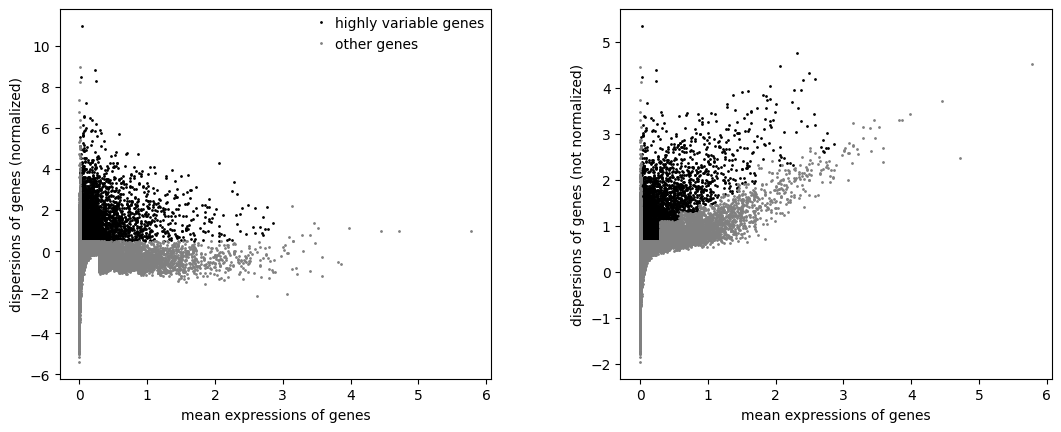

In [16]:
# highly variable genes are identified
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

sc.pl.highly_variable_genes(adata)

In [17]:
# genes that are not highly variable are filtered out
print(adata.var.highly_variable.value_counts())
adata = adata[:, adata.var.highly_variable]

highly_variable
False    26664
True      4594
Name: count, dtype: int64


## Dimensionality Reduction

As data produced from single-cell/nuclear RNA-seq is complex and multi-dimensional. It's important to reduce the dimensions while still maintaining the main axes of variation. This can be accomplished through a variety of dimensional-reducing algorithms such as PCA.

Each principle component is ranked by their variance ratio, in this case the first four principle components explains a great deal of variance in the dataset.

In [18]:
sc.tl.pca(adata, svd_solver="arpack")

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


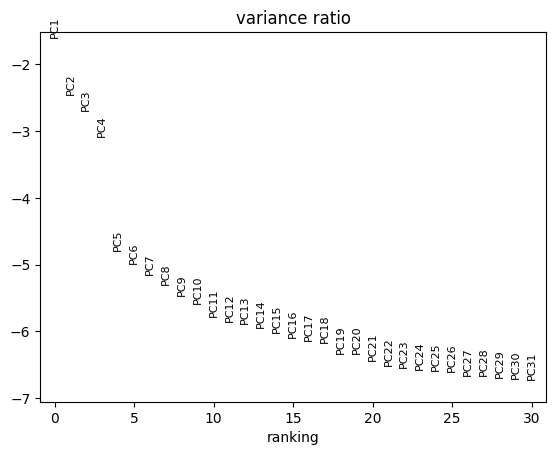

In [19]:
sc.pl.pca_variance_ratio(adata, log=True)

Nearest-neighbours distance matrix is computed in order to cluster the cells, followed by visualization with UMAP. This is done to confirm that the known cell types adhere to the clustering here.

In [20]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

In [21]:
sc.tl.umap(adata)

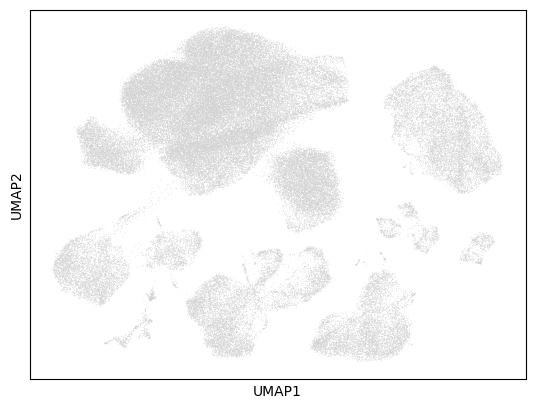

In [22]:
sc.pl.umap(adata)

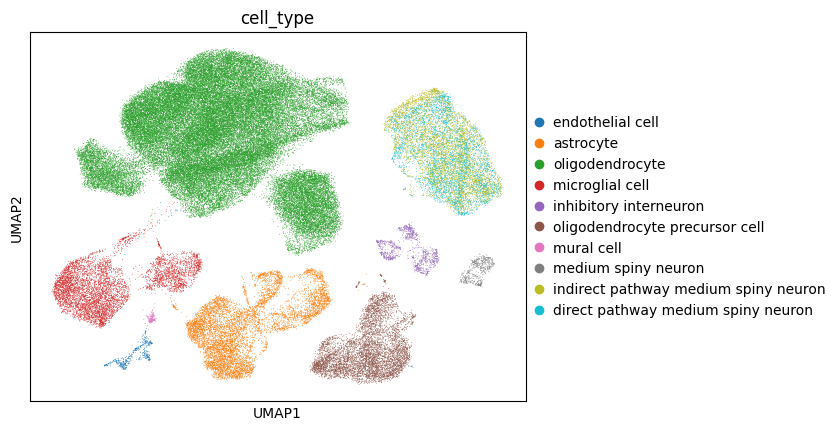

In [23]:
sc.pl.umap(adata, color=["cell_type"])

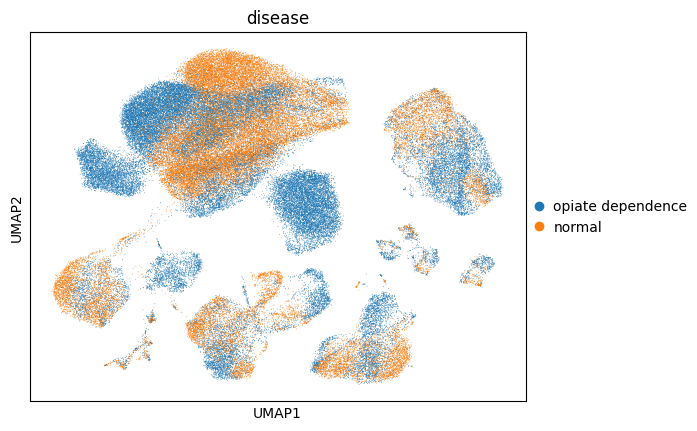

In [24]:
sc.pl.umap(adata, color=["disease"])

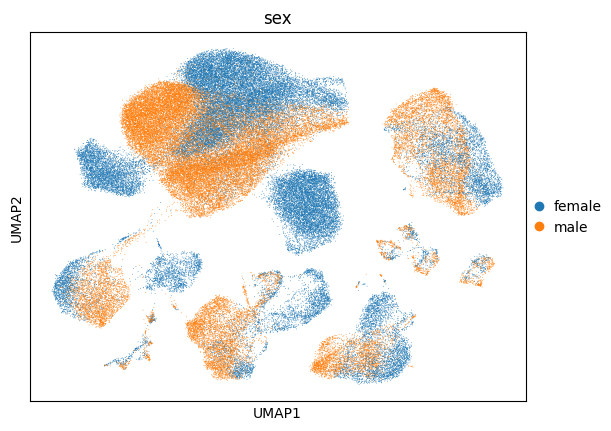

In [25]:
sc.pl.umap(adata, color=["sex"])

## Differential Gene Expression analysis to find Marker genes

After determining that the results from the clustering corresponds with known cell types, genes that are differentially expressed in a particular cluster relative to the rest can be found through this analysis. Different statistical methods can be used to find marker genes, such as the t-test and logistical regression. For the purposes of this analysis, the Wilcoxon rank-sum test will be used as it tends to have the best performance when analysing single cell/nuclear RNA-seq datasets.

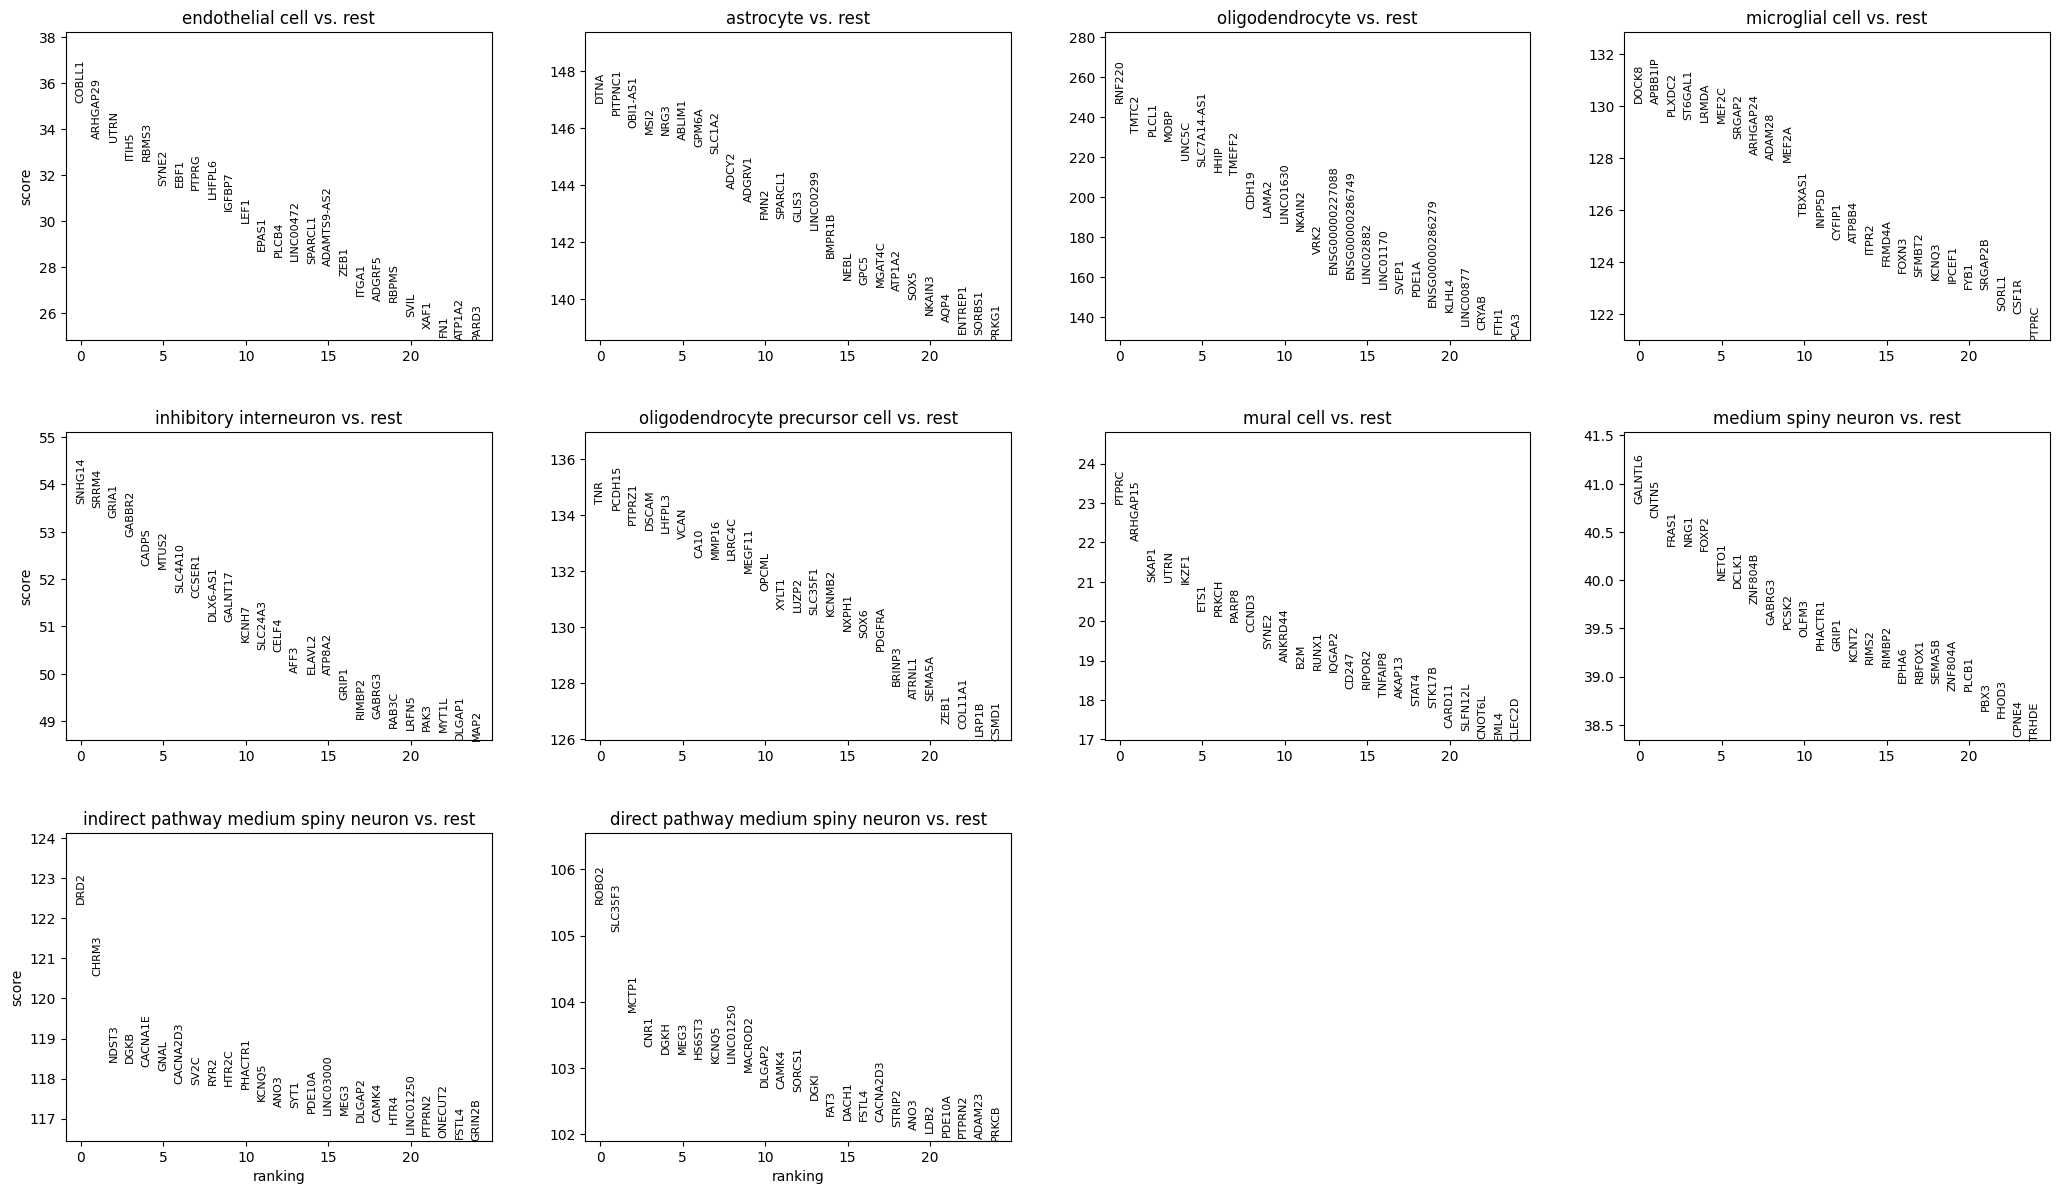

In [26]:
sc.tl.rank_genes_groups(
    adata, "cell_type", method="wilcoxon", key_added="wilcoxon_cluster_cell_type"
)
sc.pl.rank_genes_groups(
    adata,
    n_genes=25,
    sharey=False,
    gene_symbols="feature_name",
    key="wilcoxon_cluster_cell_type",
)

Results of DEG analysis is formatted into an accessible dataframe for later access

In [27]:
results = adata.uns["wilcoxon_cluster_cell_type"]

In [28]:
out = np.array([[0, 0, 0, 0, 0]])
for group in results["names"].dtype.names:
    out = np.vstack(
        (
            out,
            np.vstack(
                (
                    results["names"][group],
                    results["scores"][group],
                    results["pvals_adj"][group],
                    results["logfoldchanges"][group],
                    np.array([group] * len(results["names"][group])).astype("object"),
                )
            ).T,
        )
    )

In [29]:
markers = pd.DataFrame(
    out[1:], columns=["Gene", "scores", "pval_adj", "lfc", "cluster"]
)

In [30]:
markers = markers[(markers.pval_adj < 0.05) & (abs(markers.lfc > 1))]

In [31]:
# Rename genes from its ID to its name
feature_id_to_gene_name = (
    adata.var.reset_index()
    .loc[:, ["index", "feature_name"]]
    .rename(columns={"index": "Gene", "feature_name": "gene_name"})
)

markers_df = markers.merge(feature_id_to_gene_name, on="Gene")

# Extract the top genes based on absolute log fold change
markers_df["neg_abs_scores"] = -markers_df["scores"].abs()
markers_df = markers_df.sort_values(by=["pval_adj", "neg_abs_scores"], ascending=True)
# markers_df.head()

# Take about 25 top genes
top_genes = markers_df.head(25)["gene_name"].tolist()

## Differential expression visualization across cell types

Genes that are differentially expressed across different cell types can be visualized through a heat-map, which indicates the relative expression of particular genes across different cell types. A dot-plot can also help visualize differential expression by showing more clearly if a particular gene is highly expressed across multiple cell types.

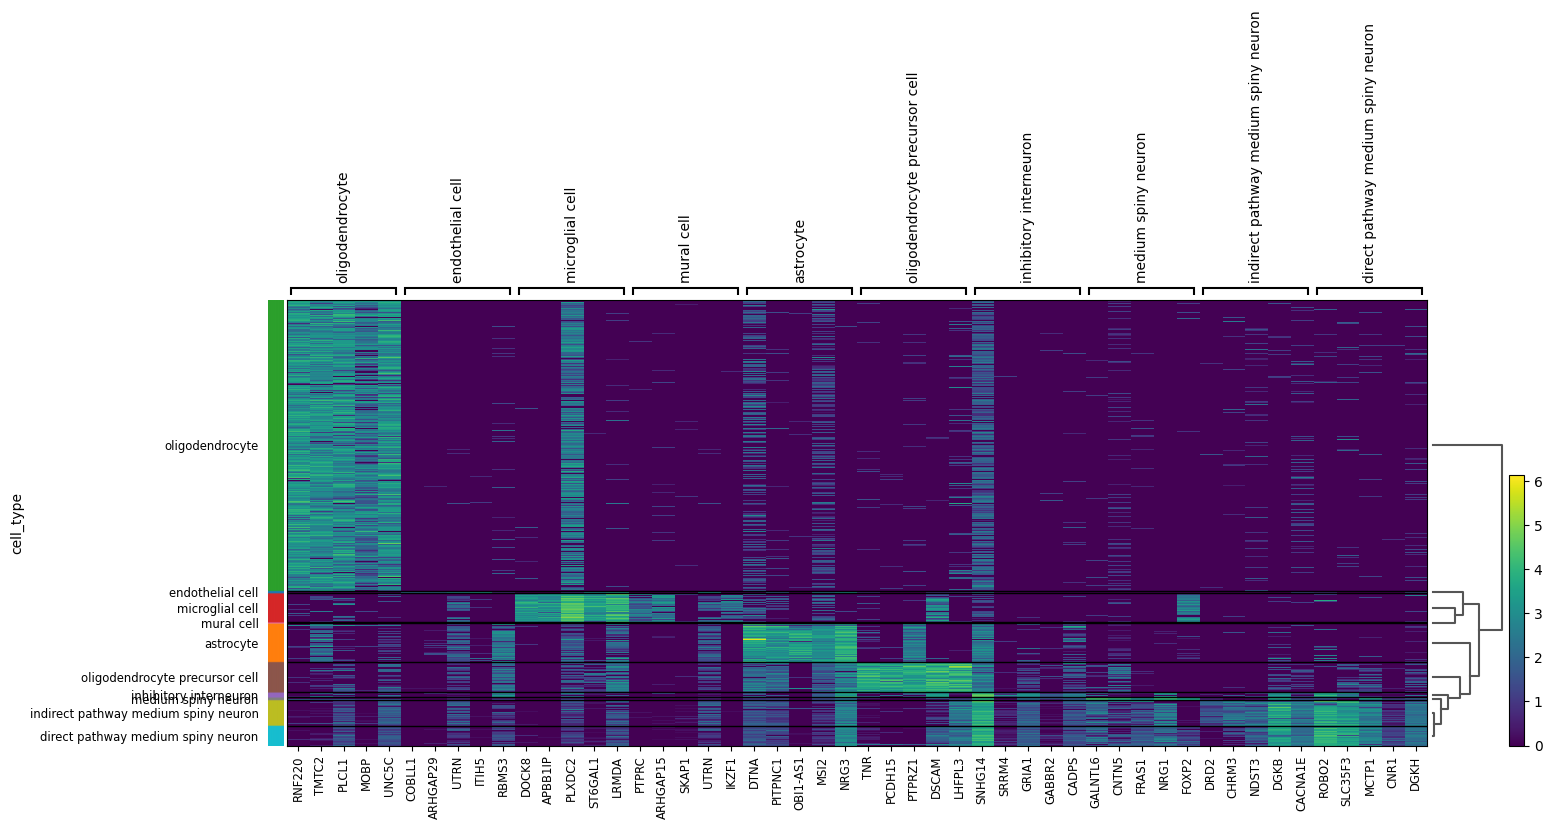

In [32]:
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    key="wilcoxon_cluster_cell_type",
    groupby="cell_type",
    show_gene_labels=True,
    gene_symbols="feature_name",
)

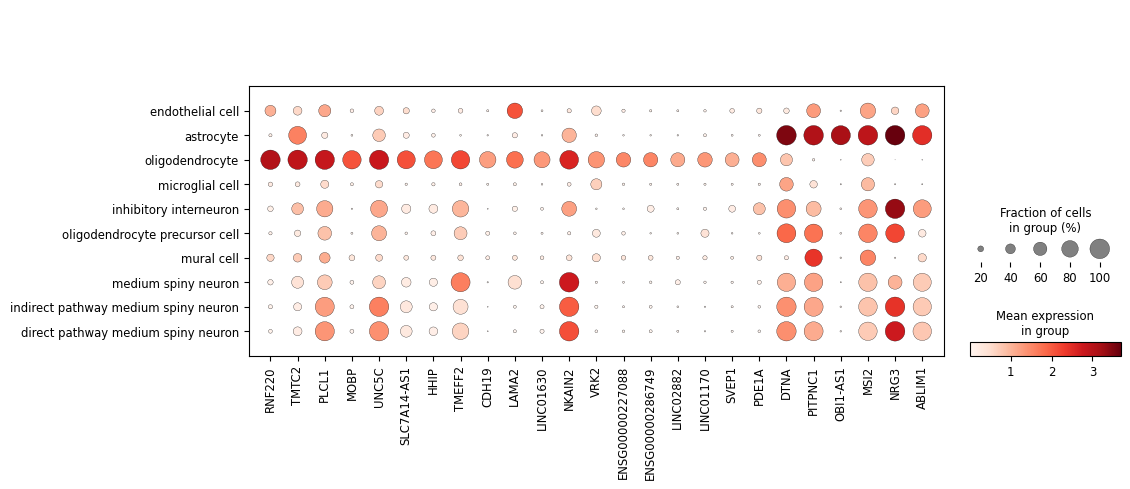

In [33]:
sc.pl.dotplot(adata, top_genes, groupby="cell_type", gene_symbols="feature_name")

## Differential Expression across different disease states using PyDESeq2

Conducting differential gene expression analysis across different conditions usually requires a different and more advanced approach. In this case, expressions for each condition is aggregated into pseudo-bulk. After this, they can be analysed with computational methods initially designed for bulk-RNA data. For the purpose of this analysis, we will be using DEseq2.

In [34]:
feature_id_to_gene_name = adata.var.reset_index().loc[:, ["index", "feature_name"]]
feature_id_to_gene_name = feature_id_to_gene_name.rename(
    columns={"index": "feature_id"}
)

Here we calculate some relevant summary statistics.

      sex  count
0  female  48613
1    male  46273
                              cell_type  count
0                       oligodendrocyte  61960
1                             astrocyte   8205
2        oligodendrocyte precursor cell   6491
3                       microglial cell   6220
4  indirect pathway medium spiny neuron   5439
5    direct pathway medium spiny neuron   4254
6                inhibitory interneuron   1061
7                   medium spiny neuron    561
8                      endothelial cell    499
9                            mural cell    196
             disease  count
0  opiate dependence  52028
1             normal  42858


/tmp/ipython-input-387/1230736942.py:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(
/tmp/ipython-input-387/1230736942.py:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(
/tmp/ipython-input-387/1230736942.py:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


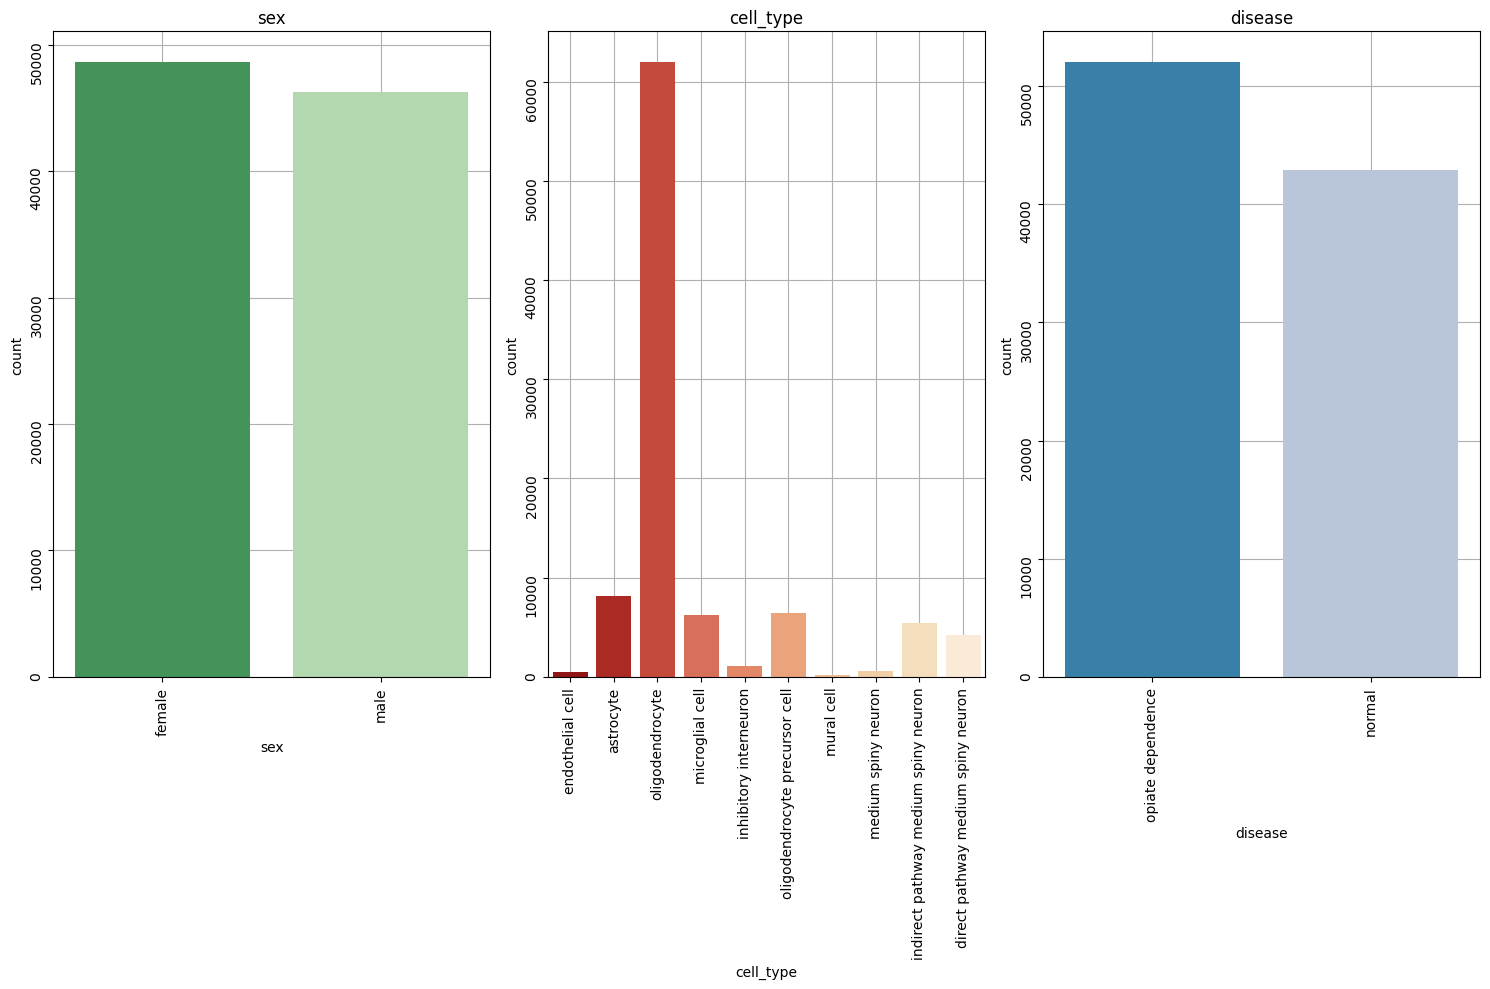

In [35]:
obs = adata.obs

columns = ["sex", "cell_type", "disease"]
palette = ["Greens", "OrRd", "PuBu"]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))

for i, column in enumerate(columns):
    df_count = (
        obs[column]
        .value_counts()
        .to_frame()
        .reset_index()
        .sort_values(by=["count"], ascending=False)
    )

    data = df_count.groupby("count").size()
    print(df_count)

    pal = sns.color_palette(palette[i], df_count.shape[0])
    rank = data.argsort().argsort()
    sns.barplot(
        df_count, x=column, y="count", ax=axes[i], palette=np.array(pal[::-1])[rank]
    )
    axes[i].set_title(column)
    axes[i].grid()
    axes[i].tick_params(rotation=90)
    axes[i].set_axisbelow(True)

plt.tight_layout()

## Differential expression of cells in different disease states (oligodendrocytes only)

As the majority of the cells are oligodendroctyes, we will focus on these cells for analysing differential expression between different disease states.

In [36]:
adata_oligo = adata[adata.obs["cell_type"] == "oligodendrocyte"]

In [37]:
import random

pseudobulk_list = []
num_pseudorep = 3

for sample in adata_oligo.obs["disease"].unique():
    samp_cell_subset = adata_oligo[adata_oligo.obs["disease"] == sample]
    # Use raw count data
    samp_cell_subset.X = samp_cell_subset.layers["counts"]

    # Create random indices to split the dataset
    indices = list(samp_cell_subset.obs_names)
    random.shuffle(indices)
    indices = np.array_split(np.array(indices), num_pseudorep)

    for i, pseudo_rep in enumerate(indices):
        # Create a pseudoreplicate object by summing gene counts across cells
        rep_adata = sc.AnnData(
            X=samp_cell_subset[indices[i]].layers["counts"].sum(axis=0),
            var=samp_cell_subset[indices[i]].var[[]],
        )

        rep_adata.obs_names = [sample + "_" + str(i)]
        rep_adata.obs["condition"] = samp_cell_subset.obs["disease"].iloc[0]
        rep_adata.obs["replicate"] = i

        pseudobulk_list.append(rep_adata)

/tmp/ipython-input-387/1776320171.py:9: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  samp_cell_subset.X = samp_cell_subset.layers["counts"]
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/tmp/ipython-input-387/1776320171.py:9: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  samp_cell_subset.X = samp_cell_subset.layers["counts"]
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X shoul

In [38]:
pseudobulk_adata = sc.concat(pseudobulk_list)
pseudobulk_adata.obs.head()

,condition,replicate
normal_0,normal,0
normal_1,normal,1
normal_2,normal,2
opiate dependence_0,opiate dependence,0
opiate dependence_1,opiate dependence,1


Pseudo-bulk and pseudo-replicates have been generated, making it suitable for PyDESeq2 analysis

In [39]:
# Extract counts
aggregate_bulk = sc.get.aggregate(
    pseudobulk_adata, by=["condition", "replicate"], func="sum"
)
counts = aggregate_bulk.to_df(layer="sum")

In [42]:
counts.head()

,ENSG00000241860,ENSG00000187608,ENSG00000215915,ENSG00000142609,ENSG00000157933,ENSG00000197921,ENSG00000157873,ENSG00000215912,ENSG00000177133,ENSG00000142611,...,ENSG00000198888,ENSG00000198763,ENSG00000198712,ENSG00000198899,ENSG00000198938,ENSG00000198840,ENSG00000198886,ENSG00000198727,ENSG00000286217,ENSG00000143546
normal_0,204.0,46.0,821.0,53.0,2386.0,1.0,28.0,45.0,0.0,52.0,...,5011.0,12123.0,24112.0,15849.0,19140.0,13793.0,15522.0,10707.0,6668.0,0.0
normal_1,227.0,46.0,792.0,56.0,2556.0,1.0,31.0,45.0,1.0,65.0,...,5213.0,12311.0,24364.0,16110.0,19765.0,14178.0,16168.0,10969.0,6731.0,0.0
normal_2,165.0,38.0,837.0,51.0,2438.0,2.0,30.0,39.0,1.0,61.0,...,5107.0,12114.0,23606.0,15606.0,19326.0,13763.0,15612.0,10614.0,6749.0,0.0
opiate dependence_0,233.0,68.0,805.0,63.0,3067.0,4.0,44.0,50.0,6.0,49.0,...,7163.0,13169.0,25725.0,19904.0,20053.0,16434.0,17456.0,11406.0,6255.0,13.0
opiate dependence_1,222.0,73.0,760.0,77.0,2903.0,0.0,43.0,35.0,2.0,57.0,...,6922.0,13220.0,24828.0,19478.0,19365.0,15426.0,17732.0,10981.0,6150.0,10.0


In [40]:
# Create DEseqDataSet object
dds = DeseqDataSet(
    counts=counts, metadata=aggregate_bulk.obs, design_factors="condition"
)

# Filter out genes with no expression in any cell
sc.pp.filter_genes(dds, min_cells=1)

/tmp/ipython-input-387/1501991822.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [41]:
dds

AnnData object with n_obs × n_vars = 6 × 4594
    obs: 'condition', 'replicate', 'n_obs_aggregated'
    var: 'n_cells'
    obsm: 'design_matrix'

In [42]:
# Run DESeq2
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 4.49 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 6.59 seconds.

Fitting LFCs...
... done in 3.34 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



PCA analysis is done here to indicate the different conditions are clustered differently, the vast majority of variation between conditions (99.09%) can be explained by the first principle component.

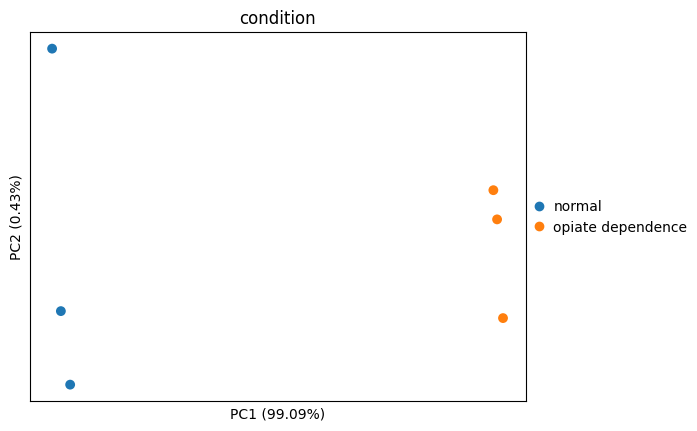

In [43]:
sc.tl.pca(dds)
sc.pl.pca(dds, color="condition", size=200, annotate_var_explained=True)

p-value and log2 fold changes are calculated for differential expression between the conditions using the Wald test.

In [44]:
# Normal vs opiate dependance
stat_res_nvsod = DeseqStats(
    dds, n_cpus=8, contrast=("condition", "normal", "opiate dependence")
)
stat_res_nvsod.summary()
de_nvsod = stat_res_nvsod.results_df
de_nvsod = de_nvsod.sort_values("stat", ascending=False).dropna()

Running Wald tests...


Log2 fold change & Wald test p-value: condition normal vs opiate dependence
                     baseMean  log2FoldChange     lfcSE       stat  \
ENSG00000241860    212.401315        0.033182  0.131981   0.251415   
ENSG00000187608     55.954462       -0.474489  0.260816  -1.819250   
ENSG00000215915    808.969057        0.265146  0.067425   3.932465   
ENSG00000142609     61.670566       -0.187984  0.233809  -0.804008   
ENSG00000157933   2707.468448       -0.050480  0.039807  -1.268118   
...                       ...             ...       ...        ...   
ENSG00000198840  14813.686877        0.044679  0.020550   2.174189   
ENSG00000198886  16553.653377        0.086518  0.020836   4.152220   
ENSG00000198727  10933.048083        0.186474  0.022151   8.418436   
ENSG00000286217   6520.372959        0.329829  0.028970  11.385111   
ENSG00000143546      5.371577       -5.755228  2.058881  -2.795318   

                       pvalue          padj  
ENSG00000241860  8.014932e-01  8.6419

... done in 18.49 seconds.



## Data wrangling and post processing

In [45]:
# The function to perform data wrangling to include log(CPM)
def calculate_log_cpm(
    adata_orig,
    df_orig: pd.DataFrame,
    condition1: str,
    condition2: str,
    cell_type: str = "oligodendrocyte",
):
    # Make a copy just in case it affects the original objects
    df = df_orig.copy()
    adata = adata_orig.copy()

    # A little bit of data wrangling

    df = df.reset_index()
    df = df.rename(columns={"index": "feature_id"})
    df = pd.merge(df, feature_id_to_gene_name, on=["feature_id"], how="left")
    df = df.rename(columns={"feature_name": "gene_symbol"})
    df["cell_type"] = cell_type

    # Create pseudobulk for only oligodendrocytes across all conditions
    pseudobulk_all_cons = sc.AnnData(
        X=adata.layers["counts"].sum(axis=0), var=adata.var[adata.var.columns.tolist()]
    )

    # Compute log(CPM)
    pseudobulk_all_cons.layers["log(CPM)"] = pseudobulk_all_cons.X

    # Normalize counts and log transform (similar to the Normalization section above)
    sc.pp.normalize_total(pseudobulk_all_cons, target_sum=1e6, layer="log(CPM)")
    sc.pp.log1p(pseudobulk_all_cons, layer="log(CPM)")

    # Extract a dataframe with feature_id and logCPM as columns
    gene_names = pseudobulk_all_cons.var_names
    log_normalized_counts = pseudobulk_all_cons.layers["log(CPM)"]

    gene_count_df = pd.DataFrame(
        {
            "feature_id": gene_names,
            "logCPM": log_normalized_counts.tolist()[0],  # Convert the array to a list
        }
    )
    df = pd.merge(df, gene_count_df, on=["feature_id"], how="left")

    # Subset the original adata
    adata_subset = adata[
        (adata.obs["disease"] == condition1) | (adata.obs["disease"] == condition2)
    ]

    # Add rank_gene_group to adata_subset
    sc_toolbox.tools.de_res_to_anndata(
        adata_subset,
        df,
        groupby="cell_type",
        score_col="logCPM",
        pval_col="pvalue",
        pval_adj_col="padj",
        lfc_col="log2FoldChange",
        key_added=f"DESeq2_{condition1}vs{condition2}_" + cell_type,
    )

    return df, adata_subset

In [46]:
df_oligo_nvsod, adata_oligo_nvsod = calculate_log_cpm(
    adata_oligo,
    df_orig=de_nvsod,
    condition1="normal",
    condition2="opiate dependance",
    cell_type="oligodendrocyte",
)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/sc_toolbox/tools/__init__.py:619: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = res_dict


There appears to be a duplicate gene in the adata_oligo_nvsod.var with different var names (ENSG00000277526 and ENSG00000254319). To resolve this, one of them (ENSG00000254319) will be filtered out from the current adata object to prevent this from becoming an issue in the downstream analysis.

In [47]:
adata_oligo_nvsod.var[adata_oligo_nvsod.var["feature_name"] == "LINC03021"]

,type,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
ENSG00000277526,lncRNA,False,LINC03021,NCBITaxon:9606,gene,1705,lncRNA,6029,False,6029,0.132486,93.900736,13096.0,True,0.078888,1.033854,1.305525
ENSG00000254319,lncRNA,False,LINC03021,NCBITaxon:9606,gene,956,lncRNA,4530,False,4530,0.077918,95.417206,7702.0,True,0.043432,0.756591,0.685141


In [48]:
test_adata_oligo_nvsod = adata_oligo_nvsod[
    :, ~adata_oligo_nvsod.var_names.isin(["ENSG00000254319"])
].copy()

In [49]:
test_adata_oligo_nvsod.var[test_adata_oligo_nvsod.var["feature_name"] == "LINC03021"]

,type,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
ENSG00000277526,lncRNA,False,LINC03021,NCBITaxon:9606,gene,1705,lncRNA,6029,False,6029,0.132486,93.900736,13096.0,True,0.078888,1.033854,1.305525


In [50]:
FDR = 0.001
LOG_FOLD_CHANGE = 2


def plot_heatmap(
    adata,
    group_key,
    group_name="cell_type",
    groupby="disease",
    cell_type="oligodendrocyte",
):
    res = sc.get.rank_genes_groups_df(adata, group=cell_type, key=group_key)
    res.index = res["names"].values
    res = res[
        (res["pvals_adj"] < FDR) & (abs(res["logfoldchanges"]) > LOG_FOLD_CHANGE)
    ].sort_values(by=["logfoldchanges"])

    # # return res
    # #print(res[res.index == "SGCZ"])
    print(f"Plotting {len(res)} genes...")
    markers = list(res.index)
    # #var names corrosponding to LINC03021 will probably need to be deleted
    # # print(markers)
    sc.pl.heatmap(
        adata[adata.obs[group_name] == cell_type].copy(),
        markers,
        groupby=groupby,
        swap_axes=True,
        gene_symbols="feature_name",
    )


def volcano_plot(
    adata,
    group_key,
    group_name="cell_type",
    groupby="label",
    title=None,
    cell_type="oligodendrocyte",
):
    result = sc.get.rank_genes_groups_df(adata, group=cell_type, key=group_key).copy()
    result["-logQ"] = -np.log(result["pvals"].astype("float"))
    lowqval_de = result.loc[abs(result["logfoldchanges"]) > LOG_FOLD_CHANGE]
    other_de = result.loc[abs(result["logfoldchanges"]) <= LOG_FOLD_CHANGE]

    fig, ax = plt.subplots()
    sns.regplot(
        x=other_de["logfoldchanges"],
        y=other_de["-logQ"],
        fit_reg=False,
        scatter_kws={"s": 6},
    )
    sns.regplot(
        x=lowqval_de["logfoldchanges"],
        y=lowqval_de["-logQ"],
        fit_reg=False,
        scatter_kws={"s": 6},
    )
    ax.set_xlabel("log2 FC")
    ax.set_ylabel("-log Q-value")

    if title is None:
        title = group_key.replace("_", " ")
    plt.title(title)
    plt.show()

Plotting 44 genes...


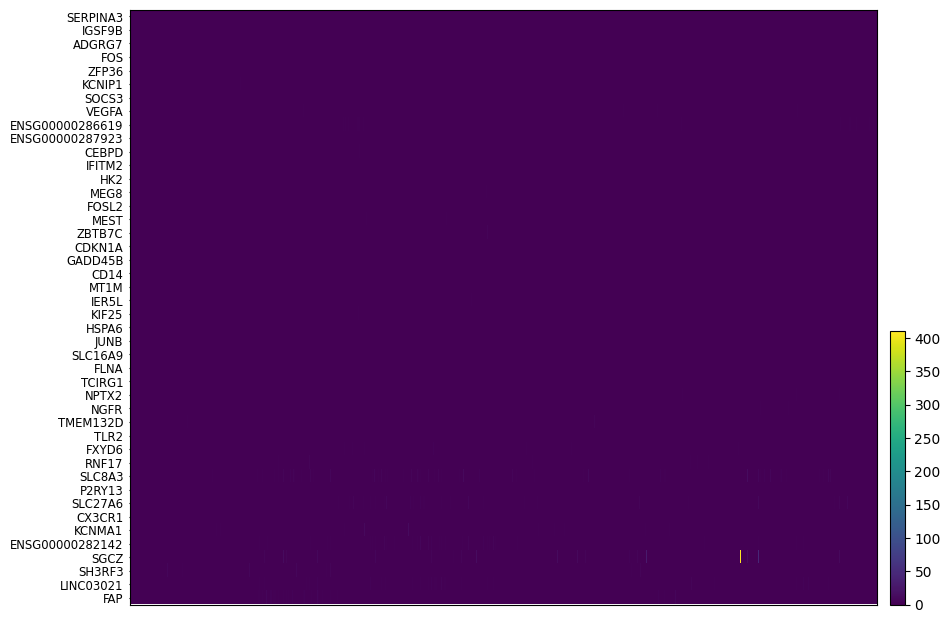

In [51]:
plot_heatmap(test_adata_oligo_nvsod, "DESeq2_normalvsopiate dependance_oligodendrocyte")

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


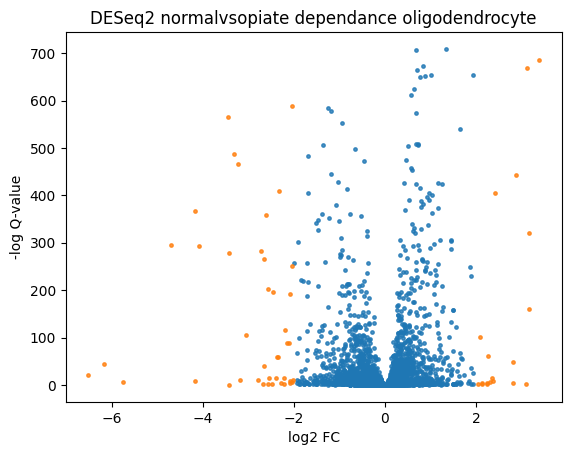

In [52]:
volcano_plot(test_adata_oligo_nvsod, "DESeq2_normalvsopiate dependance_oligodendrocyte")

## Gene set enrichment and pathway analysis associated with each cluster


After identifying differentially expressed genes between conditions, gene set enrichment and pathway analysis can be done to further investigate biological variation of cell types between conditions. This involves identifying potential regulatory pathways that these DE genes may belong to based on a curated set of known molecular pathways. By doing this, we can identify which molecular pathways our DE genes are present in.

For this analysis, we will be using the reactome pathway database.  

In [53]:
# Downloading reactome pathways
from pathlib import Path

if not Path("c2.cp.reactome.v7.5.1.symbols.gmt").is_file():
    !wget https://data.broadinstitute.org/gsea-msigdb/msigdb/release/7.5.1/c2.cp.reactome.v7.5.1.symbols.gmt

--2026-03-01 13:45:38--  https://data.broadinstitute.org/gsea-msigdb/msigdb/release/7.5.1/c2.cp.reactome.v7.5.1.symbols.gmt
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 770046 (752K) [text/plain]
Saving to: ‘c2.cp.reactome.v7.5.1.symbols.gmt’

c2.cp.reactome.v7.5 100%[===================>] 752.00K   837KB/s    in 0.9s    

2026-03-01 13:45:39 (837 KB/s) - ‘c2.cp.reactome.v7.5.1.symbols.gmt’ saved [770046/770046]



In [54]:
def gmt_to_decoupler(pth: Path) -> pd.DataFrame:
    """
    Parse a gmt file to a decoupler pathway dataframe.
    """
    from itertools import chain, repeat

    pathways = {}

    with Path(pth).open("r") as f:
        for line in f:
            name, _, *genes = line.strip().split("\t")
            pathways[name] = genes

    return pd.DataFrame.from_records(
        chain.from_iterable(zip(repeat(k), v) for k, v in pathways.items()),
        columns=["geneset", "genesymbol"],
    )

In [55]:
reactome = gmt_to_decoupler("c2.cp.reactome.v7.5.1.symbols.gmt")

In [56]:
reactome

,geneset,genesymbol
0,REACTOME_INTERLEUKIN_6_SIGNALING,JAK2
1,REACTOME_INTERLEUKIN_6_SIGNALING,TYK2
2,REACTOME_INTERLEUKIN_6_SIGNALING,CBL
3,REACTOME_INTERLEUKIN_6_SIGNALING,STAT1
4,REACTOME_INTERLEUKIN_6_SIGNALING,IL6ST
...,...,...
89471,REACTOME_ION_CHANNEL_TRANSPORT,FXYD7
89472,REACTOME_ION_CHANNEL_TRANSPORT,UBA52
89473,REACTOME_ION_CHANNEL_TRANSPORT,ATP6V1E2
89474,REACTOME_ION_CHANNEL_TRANSPORT,ASIC5


In [57]:
# Filtering genesets to match behaviour of fgsea
geneset_size = reactome.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [58]:
feature_id_to_gene_name

,feature_id,feature_name
0,ENSG00000241860,ENSG00000241860
1,ENSG00000187608,ISG15
2,ENSG00000215915,ATAD3C
3,ENSG00000142609,CFAP74
4,ENSG00000157933,SKI
...,...,...
4589,ENSG00000198840,MT-ND3
4590,ENSG00000198886,MT-ND4
4591,ENSG00000198727,MT-CYB
4592,ENSG00000286217,LINC00279


In [59]:
de_nvsod.index.name = "feature_id"

In [60]:
final_df = pd.merge(de_nvsod, feature_id_to_gene_name, on=["feature_id"], how="left")

In [61]:
feature_name_dict = dict(
    zip(feature_id_to_gene_name["feature_id"], feature_id_to_gene_name["feature_name"])
)

In [62]:
final_df.index = de_nvsod.index.map(feature_name_dict)

In [63]:
# Filtering genesets to match behaviour of fgsea
geneset_size = reactome.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [64]:
final_reactome = reactome[reactome["geneset"].isin(gsea_genesets)]
final_reactome = final_reactome.rename(
    columns={"geneset": "source", "genesymbol": "target"}
)
final_reactome

,source,target
11,REACTOME_APOPTOSIS,BAD
12,REACTOME_APOPTOSIS,CFLAR
13,REACTOME_APOPTOSIS,PSMB1
14,REACTOME_APOPTOSIS,PSMC4
15,REACTOME_APOPTOSIS,BID
...,...,...
89471,REACTOME_ION_CHANNEL_TRANSPORT,FXYD7
89472,REACTOME_ION_CHANNEL_TRANSPORT,UBA52
89473,REACTOME_ION_CHANNEL_TRANSPORT,ATP6V1E2
89474,REACTOME_ION_CHANNEL_TRANSPORT,ASIC5


In [65]:
# extract scores
stats = (
    final_df.rename_axis("names")
    .sort_values("stat", key=np.abs, ascending=False)[["stat"]]
    .rename_axis(["oligodendrocyte"], axis=1)
)
stats

oligodendrocyte,stat
names,
PDE1A,74.715990
CALN1,64.168947
GRIA4,58.148371
LINC01505,54.092717
SGCD,51.945064
...,...
HSPH1,0.002651
ENSG00000273338,0.001138
HRH1,0.000419


In [66]:
# run decoupler
scores, pvals = decoupler.mt.gsea(
    stats.T,
    final_reactome,
)

In [67]:
gsea_results = (
    pd.concat({"score": scores.T, "pval": pvals.T}, axis=1)
    .droplevel(level=1, axis=1)
    .sort_values("pval", ascending=True)
    .rename_axis("source")
)

In [68]:
gsea_results

,score,pval
source,,
REACTOME_NEURONAL_SYSTEM,1.557183,0.000000
REACTOME_NEUROTRANSMITTER_RECEPTORS_AND_POSTSYNAPTIC_SIGNAL_TRANSMISSION,1.685914,0.000000
REACTOME_INFLUENZA_INFECTION,-2.021802,0.000000
REACTOME_REGULATION_OF_EXPRESSION_OF_SLITS_AND_ROBOS,-2.221868,0.000000
REACTOME_NONSENSE_MEDIATED_DECAY_NMD,-2.334310,0.000000
...,...,...
REACTOME_REGULATION_OF_MECP2_EXPRESSION_AND_ACTIVITY,-0.426420,0.999086
REACTOME_RNA_POLYMERASE_II_TRANSCRIBES_SNRNA_GENES,0.409723,1.000000
REACTOME_COSTIMULATION_BY_THE_CD28_FAMILY,0.387441,1.000000


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/_core/plot.py:1043: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.savefig(buffer, dpi=dpi, format="png", bbox_inches="tight")


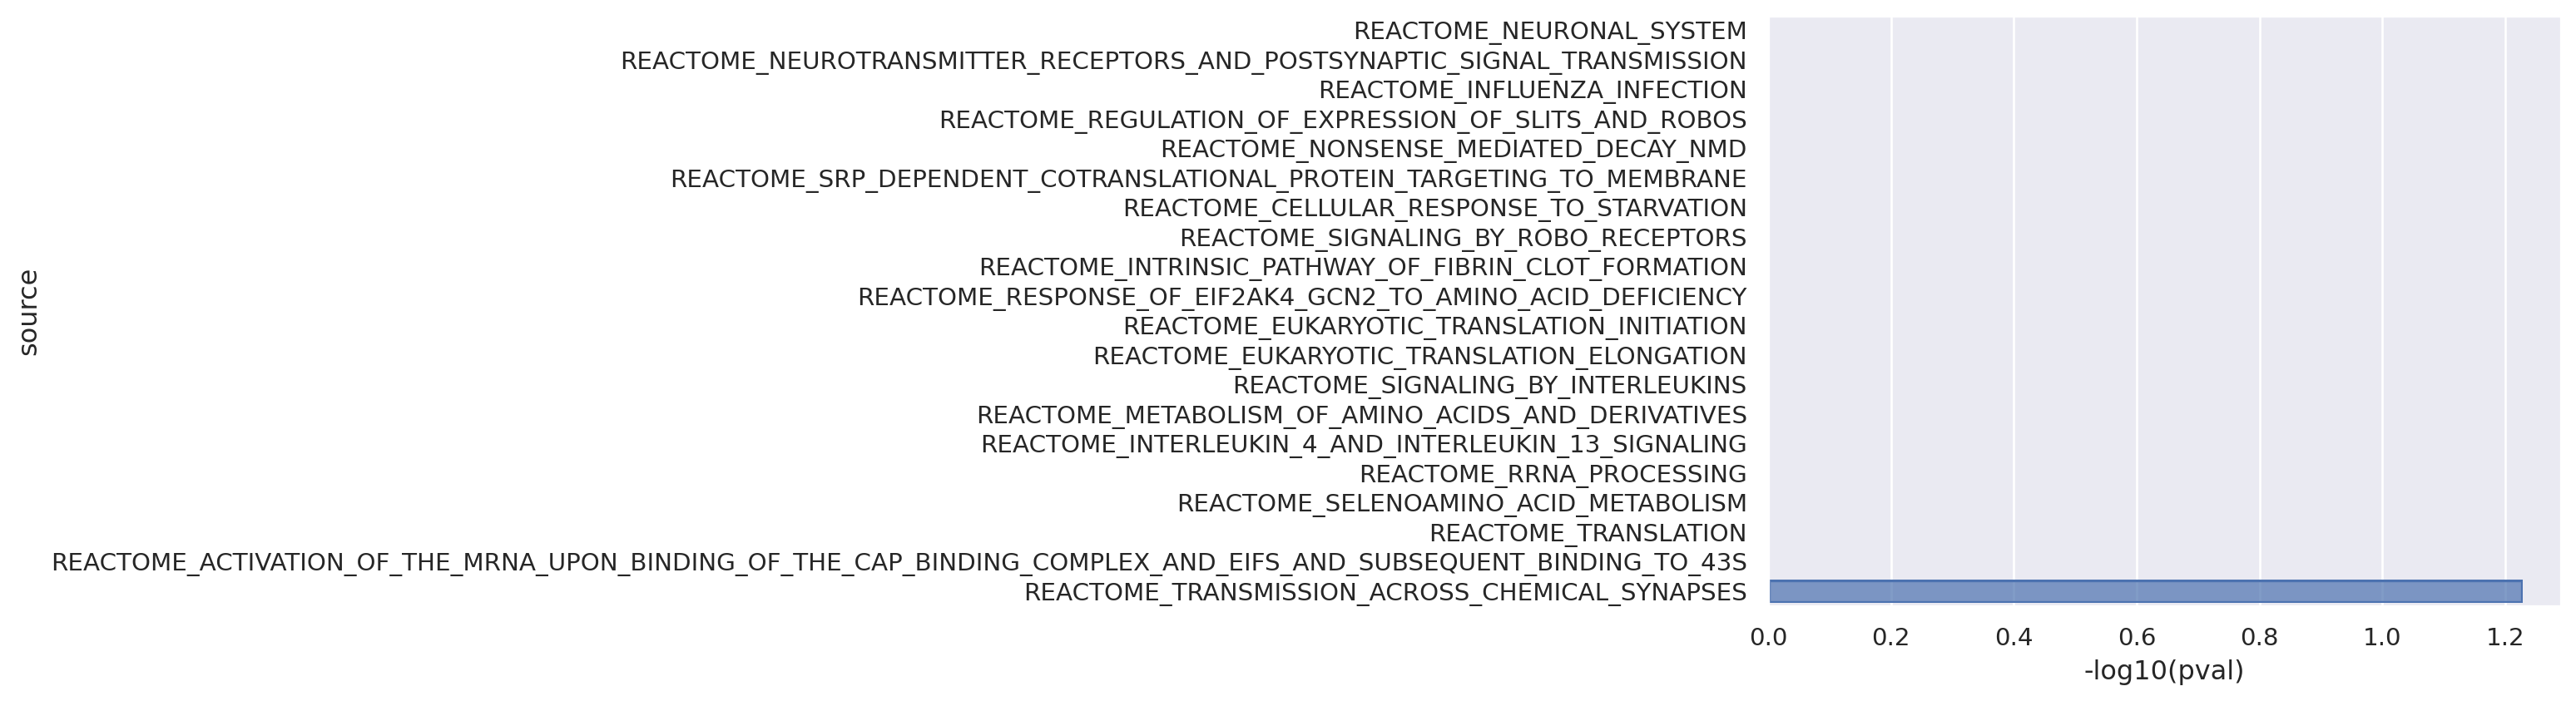

In [69]:
# plot top 20 pathways signifcantly enriched in oligodendrocytes
(
    so.Plot(
        data=(
            gsea_results.head(20).assign(
                **{"-log10(pval)": lambda x: -np.log10(x["pval"])}
            )
        ),
        x="-log10(pval)",
        y="source",
    ).add(so.Bar())
)

## Results and Discussion

This jupyter notebook presents the results of single-cell/nuclear RNA-Seq analysis based on datasets extracted from human dorsal striatum (n=12), the dataset includes healthy individuals as well as those with opioid use disorder (OUD). At the introduction, we set three research questions to explore in the analysis which are discussed below.

* The clusters that were ascertained in this analysis matches with cell-types that were already known for this dataset. However, some of the marker genes did not fully match what was found in the associated paper. For example, a number of the oligodendroglia-specific marker genes found in this analysis were not reported in the paper by N.Phan et al (2024), and some of the marker genes found in that paper are not reported here. This may be due to differences in the preprocessing and quality control pipelines used in this analysis compared to the paper.


* The differential gene expression analysis between different conditions among oligodendrocytes indicated 44 genes that were differential expressed when filtering for a minimum false discovery rate (p-values) of 0.001 and log-fold changes above 2.


* Using the results of DE analysis, the gene-set enrichment and pathway analysis indicate a variety of regulatory pathways that may be relevant in OUD. Although a number of these pathways produced p-values that were zero as shown in the final plot, making it difficult to compare between them. Of particular interest is the reactome neuronal system pathway, which are involved in chemical synaptic transmission, and are the main means by which communication occurs between nerves.